## **LIBRERÍAS**

In [ ]:
!pip install soccerplots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from soccerplots.radar_chart import Radar

from sqlalchemy import create_engine, select
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker

import glob
import os

pd.set_option('display.max_rows',30)
pd.set_option('display.max_columns',None)

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


## **CONEXIÓN BBDD / Excel**

In [ ]:
#leemos el csv
df = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/MLPFD/Salida/s_Scout_TempActual_Jugadores.xlsx')


In [ ]:
# Configuración de la conexión a PostgreSQL
usuario = "avnadmin"
contrasena = "AVNS_Snql1CSp1zYrJCH6cXE"
servidor = "my-database-pg-my-data22.f.aivencloud.com"
puerto = "13676"
base_datos = "my_wyscout"

# Crea la cadena de conexión
conexion_str = f'postgresql+psycopg2://{usuario}:{contrasena}@{servidor}:{puerto}/{base_datos}'
engine = create_engine(conexion_str)

In [ ]:
s_sql = text("""SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios/90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos/90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from jugadores j
union
SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios/90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos/90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from hist_jugadores hj
;""")

In [ ]:
# Ejecutar la consulta SQL
df = pd.read_sql(s_sql, conexion_str)  # Cargar resultados en un DataFrame

In [ ]:
df_allplayers = df.copy()
df_allplayers.fillna(0, inplace=True)

In [ ]:
df_allplayers.head(2)

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios /90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos /90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
0,1DIVI,2018-2019,Central,A. Ba,Tondela,Rayo Vallecano,"RCB, CB",33,100000,2024-06-30,26,2241,1,1.11,0,0.17,14.22,60.73,Senegal,Senegal,derecho,197,79,no,11.77,5.86,68.49,4.34,59.26,0.60,0.32,0.0,0.08,0.16,0.16,0.04,0.12,0.12,0.00,0.0,54.29,1.41,0.60,0.88,1,0.04,0.0,12.5,0.0,0.04,7.15,0.0,22.35,39.61,ESP,0.0,0.28,34.70,3.61,16.91,2.69,42.86,0.32,5.58,17.31,8.51,24.98,40.40,0,0.0,0,10.02,33.33,33.33,0.0,84.99,90.97,60.00,0.0,72.68,98.65,94.43,61.32,60.0,0.20,0,0.0,8,0.32,0.0,0.0,4,2,0.08,0.0,50.0,0.56,0.0,0.0,0.0,0.44,0.01,0.0,0.0,0.04,0.04,0.84,0.00,0.0,0.0,0.0,2025-05-23 12:56:25.752890,1,0.0,0,0.08,2.97,0.0,48.92,0.16
1,1DIVI,2018-2019,Central,Adrián Diéguez,Jagiellonia Białystok,Huesca,"CB, LCB",28,1000000,2025-06-30,9,815,0,0.28,0,0.00,15.24,58.70,Spain,Spain,izquierdo,188,78,no,11.60,7.84,67.61,3.09,57.14,1.21,0.77,0.0,0.00,0.11,0.22,0.00,0.00,0.00,0.22,0.0,71.43,1.55,0.77,0.77,0,0.00,0.0,0.0,0.0,0.00,5.08,0.0,20.88,36.08,ESP,0.0,0.44,17.89,2.65,12.26,0.44,0.00,0.00,4.20,6.52,4.53,10.82,22.09,0,0.0,0,6.48,0.00,0.00,0.0,75.50,85.80,33.33,0.0,69.37,85.71,86.44,53.66,75.0,0.88,0,0.0,1,0.11,0.0,0.0,3,0,0.00,0.0,100.0,0.33,0.0,0.0,0.0,0.22,0.00,0.0,0.0,0.03,0.00,1.55,0.11,0.0,0.0,0.0,2025-05-23 12:56:25.752890,0,0.0,0,0.33,0.77,0.0,31.58,0.33


In [ ]:
fase_defensiva = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
                #'Duelos aéreos en los 90.1',
                'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos defensivos/90','Entradas/90',
                'Faltas/90','Interceptaciones/90','Posesión conquistada después de una entrada',
                'Posesión conquistada después de una interceptación','Tarjetas amarillas','Tarjetas amarillas/90',
                'Tarjetas rojas','Tarjetas rojas/90','Tiros interceptados/90']

abp = ['Córneres/90','Penaltis a favor','Penaltis realizados %','Tiros libres directos %',
       'Tiros libres directos/90','Tiros libres/90']

acc_ofensivas = ['Acciones de ataque exitosas/90','Aceleraciones/90','Asistencias','Asistencias/90',
                #'Asistencias/90.1',
                'Carreras en progresión/90','Centros al área pequeña/90','Centros desde la banda derecha/90',
                'Centros desde la banda izquierda/90','Centros/90','Duelos atacantes ganados %',
                'Duelos atacantes/90','Faltas recibidas/90','Goles','Goles (excepto los penaltis)',
                'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90',
                'Goles/90','Pases largos recibidos/90','Pases recibidos /90','Precisión centros %',
                'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
                'Regates realizados %','Regates/90','Remates','Remates/90','Tiros a la portería %',
                'Toques en el área de penalti/90','xG','xG/90']

fisica = ['Total Distance per 90','Running Distance per 90 (15-20 km/h)','HSR Distance per 90 (20-25 km/h)',
          'Sprinting Distance per 90 (+25 km/h)','HI Distance per 90 (+20 km/h)','Meter/Min','Max Speed (km/h)',
          'Count Medium Acceleration per 90 (1.5 m/s² to 3 m/s²)','Count High Acceleration per 90 (+3 m/s²)',
          'Count Medium Deceleration per 90 (-1.5 m/s² to -3 m/s²)','Count High Deceleration per 90 (-3 m/s²)',
          'Count HSR per 90 (20-25 km/h)','Count Sprint per 90 (+25 km/h)','Count HI per 90 (+20 km/h)']

jugadas_clave = ['Asistencias','Asistencias/90',
                #'Asistencias/90.1',
                'Ataque en profundidad/90','Centros desde el último tercio/90','Desmarques/90',
                'Jugadas claves/90','Pases al área de penalti/90','Pases en el último tercio/90',
                'Pases en profundidad/90','Pases hacía el área pequeña %','Pases progresivos/90',
                'Precisión desmarques %','Precisión pases en el último tercio %',
                'Precisión pases en profundidad %','Precisión pases progresivos %','Second assists/90',
                'Third assists/90','xA','xA/90']
organizacion = ['Longitud media pases largos, m','Longitud media pases, m','Pases cortos / medios /90',
                'Pases hacia adelante/90','Pases hacia atrás/90','Pases largos/90','Pases laterales/90',
                'Pases/90','Precisión pases %','Precisión pases cortos / medios %',
                'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
                'Precisión pases laterales %']

portero = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
          #'Duelos aéreos en los 90.1',
          'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos ganados %','Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Longitud media pases largos, m',
          'Longitud media pases, m','Paradas %','Pases hacia adelante/90',
          'Pases hacía atrás recibidos del arquero/90','Pases hacia atrás/90','Pases largos/90',
          'Pases laterales/90','Pases/90','Porterías imbatidas en los 90','Precisión pases %',
          'Precisión pases cortos / medios %','Precisión pases hacia adelante %',
          'Precision pases hacia atrás %','Precisión pases largos %','Precisión pases laterales %',
          'Remates en contra','Remates en contra/90','Salidas/90','xG en contra','xG en contra/90']

Finalización = ['Goles', 'Goles (excepto los penaltis)', 'Goles de cabeza', 'Goles de cabeza/90',
                'Goles hechos %', 'Goles, excepto los penaltis/90', 'Goles/90', 'Remates', 'Remates/90',
                'Tiros a la portería %', 'xG/90'
                ]

Delantero = ['Goles/90', 'Goles', 'Duelos atacantes ganados %', 'Duelos aéreos ganados %',
             'Remates/90', 'Regates/90',
             'Toques en el área de penalti/90', 'Tiros a la portería %', 'xG/90',
             'Regates realizados %'
            ]

Extremo = ['Regates realizados %', 'Centros desde la banda izquierda/90', 'Centros desde la banda derecha/90',
           'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
           'Duelos atacantes ganados %', 'Goles', 'xG/90', 'Aceleraciones/90'
          ]

In [ ]:
#Buscar los jugadores
df_allplayers[df_allplayers['Jugador'].str.contains('Mbappé')]

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios /90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos /90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
4857,1DIVI,2024-2025,Delantero,K. Mbappé,Real Madrid,Real Madrid,CF,26,180000000,2029-06-30,34,3125,31,26.67,3,6.00,16.19,40.39,France,France,derecho,180,81,no,0.89,1.09,47.37,0.32,36.36,0.03,6.13,0.09,1.18,2.25,3.89,0.40,0.37,1.61,0.23,0.0,40.77,12.79,1.09,0.72,24,0.0,0.0,19.018,0.0,0.89,0.35,0.66,15.89,28.06,ESP,0.0,2.42,28.77,2.33,6.45,0.06,66.67,1.84,1.44,10.02,2.42,29.75,31.80,9,77.778,0,0.52,25.0,30.77,23.81,83.88,87.49,91.36,50.0,79.46,90.23,86.21,83.33,47.41,6.68,0,0.0,163,4.69,0.0,0.14,3,1,0.03,0.09,51.53,0.0,25.0,0.12,0.12,7.32,0.17,0.0,0.0,0.77,0.69,0.04,0.66,0.26,1.21,0.17,2025-06-27 14:39:39.858545,0,0.0,0,0.29,7.37,62.5,76.0,0.09
5527,1DIVI,2025-2026,Delantero,K. Mbappé,Real Madrid,Real Madrid,CF,26,180000000,2029-06-30,4,386,4,3.72,1,1.04,15.62,41.79,France,France,derecho,180,81,no,0.70,0.70,33.33,1.17,20.00,0.00,5.60,0.23,2.33,1.87,2.10,0.47,0.23,0.47,0.00,0.0,45.10,11.89,1.40,0.47,3,0.0,0.0,17.391,0.0,0.93,0.47,1.87,14.55,31.25,ESP,0.0,2.10,33.81,2.33,6.30,1.17,66.67,0.23,1.17,12.82,1.63,31.01,35.44,1,100.000,0,0.67,100.0,100.00,100.00,88.82,90.34,70.00,0.0,85.19,97.14,89.09,85.71,62.50,5.60,0,0.0,23,5.36,0.0,0.00,2,0,0.00,0.00,30.43,0.0,0.0,0.47,0.47,5.83,0.24,0.0,0.0,0.87,0.70,0.00,0.70,0.23,0.23,0.23,2025-09-16 08:07:04.786876,0,0.0,0,0.23,8.16,0.0,40.0,0.47


In [ ]:
#seleccionamos los dos jugadores que hemos buscado en el paso anterior y los ponemos aquí
df_comparativa = df_allplayers[(
                              (df_allplayers['Jugador'].isin(['K. Mbappé', 'V. Muriqi']))
                              #& df_allplayers['Posición específica'].isin(['LW'])
                              & df_allplayers['Temporada'].isin(['2024-2025'])
                              )].reset_index()

In [ ]:
metrica = Delantero

jugador1 = df_comparativa['Jugador'][0]
jugador2 = df_comparativa['Jugador'][1]


equipo1 = df_comparativa['Equipo durante el período seleccionado'][0]
equipo2 = df_comparativa['Equipo durante el período seleccionado'][1]

print(jugador1 + " - " + equipo1)
print(jugador2 + " - " + equipo2)

K. Mbappé - Real Madrid
V. Muriqi - Mallorca


In [ ]:
#DEPENDE DE LA POSICIÓN DEL JUGADOR
#OJO, CAMBIAR EL NOMBRE DE LAS METRICAS A ANALIZAR ***********************************************
df_comparativa = df_comparativa[["Jugador"] + metrica].dropna().reset_index(drop=True)

In [ ]:
df_comparativa

,Jugador,Goles/90,Goles,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,Regates realizados %
0,K. Mbappé,0.89,31,40.77,36.36,4.69,6.68,7.32,51.53,0.77,47.41
1,V. Muriqi,0.29,7,28.90,49.62,1.84,0.90,3.76,40.00,0.40,50.00


In [ ]:
#separar columnas para que el radar las entienda
#obtener parametros
params = list(df_comparativa.columns)
params = params[1:]

params

['Goles/90',
 'Goles',
 'Duelos atacantes ganados %',
 'Duelos aéreos ganados %',
 'Remates/90',
 'Regates/90',
 'Toques en el área de penalti/90',
 'Tiros a la portería %',
 'xG/90',
 'Regates realizados %']

In [ ]:
#rango de datos
ranges = []
a_values = []
b_values = []

for x in params:
  a = min(df_comparativa[params][x])
  a = a - (a * 0.25)

  b = max(df_comparativa[params][x])
  b = b + (b * 0.25)

  ranges.append((a,b))

for x in range(len(df_comparativa['Jugador'])):
  if df_comparativa['Jugador'][x] == jugador1:
    a_values = df_comparativa.iloc[x].values.tolist()
  if df_comparativa['Jugador'][x] == jugador2:
    b_values = df_comparativa.iloc[x].values.tolist()

a_values = a_values[1:]
b_values = b_values[1:]

values = [a_values, b_values]

In [ ]:
values

[[np.float64(50.56),
  np.float64(0.99),
  np.float64(0.17),
  np.float64(25.0),
  np.float64(47.83),
  np.float64(36.96),
  np.int64(4),
  np.float64(0.16),
  np.float64(0.22)],
 [np.float64(51.275),
  np.float64(2.075),
  np.float64(0.3225),
  np.float64(25.0),
  np.float64(32.505),
  np.float64(39.6225),
  np.int64(2),
  np.float64(0.1975),
  np.float64(0.2825)]]

In [ ]:
from re import sub
#titulos y texto que aparecerán en el gráfico
title = dict(title_name = jugador1,
             title_color = 'blue',
             subtitle_name = equipo1,
             subtitle_color = 'blue',
             title_name_2 = jugador2,
             title_color_2 = 'red',
             subtitle_name_2 = equipo2,
             subtitle_color_2 = 'red',
             title_font_size = 18,
             subtitle_font_size = 15,
             )

endnote = '@ManuelFLP'
CREDIT_1 = 'La Liga' + ' / ' + 'Temp.25-26'
CREDIT_2 = 'Datos: Wyscout'
endnote = f"{CREDIT_1}\n{CREDIT_2}\n{endnote}"
#f"{endnote}\n{CREDIT_1}\n{CREDIT_2}"

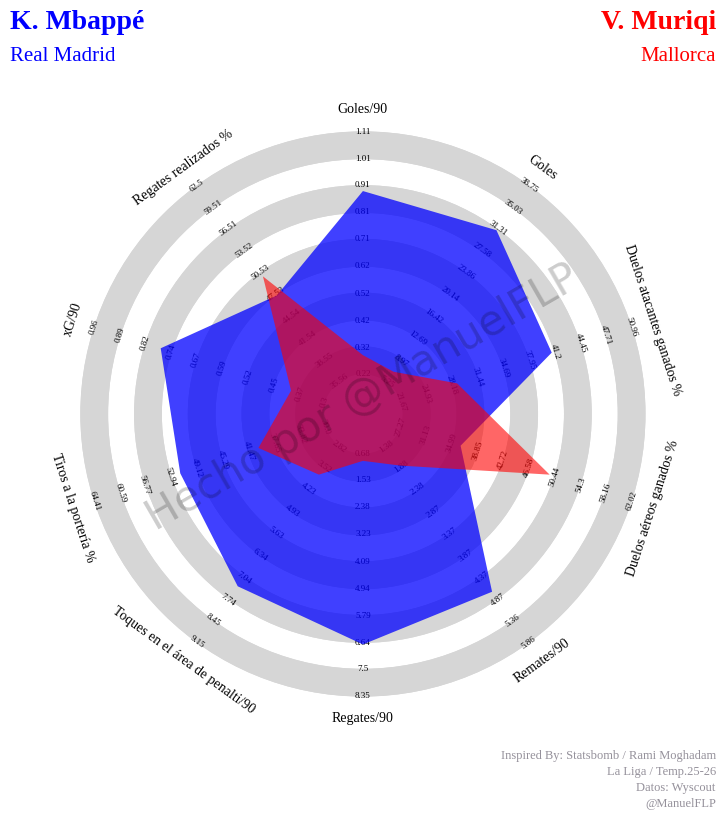

In [ ]:
#pintamos el radar
#fig, ax = plt.subplots(figsize=(16, 12))
radar = Radar()

fig, ax = radar.plot_radar(ranges = ranges,
                           params = params,
                           values = values,
                           radar_color = ['blue', 'red'],
                           alphas=[0.75,0.6],
                           title=title,
                           endnote=endnote,
                           compare=True )

#marca de agua
plt.text(0.5, 0.5, "Hecho por @ManuelFLP",
    transform=plt.gca().transAxes, fontsize=30, color="black",
    alpha=0.2, ha="center", va="center", rotation=30)

# Cierra la figura (fig) para evitar que se muestre el cuadrado vacío.
#plt.close(fig)

# Mostramos el gráfico.
plt.show()
